In [1]:
import numpy as np
from sklearn import datasets

In [2]:
iris = datasets.load_iris()
X = iris.data[:5]
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [3]:
Y = iris.target[:5]
Y

array([0, 0, 0, 0, 0])

In [4]:
Y_names = iris.target_names[:5]
Y_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [5]:
from sklearn.datasets import load_sample_image
china = load_sample_image('china.jpg')
china.shape

(427, 640, 3)

In [6]:
from PIL import Image
Image.fromarray(china).show()
Image.fromarray(china[:,:,0]).show()
Image.fromarray(china[:,:,1]).show()
Image.fromarray(china[:,:,2]).show()

In [7]:
from sklearn.neural_network import MLPClassifier

In [9]:
np.random.seed(8675309)

x0 = np.random.random(50) - 0.3
y0 = np.random.random(50) + 0.3

x1 = np.random.random(50) + 0.3
y1 = np.random.random(50) - 0.3

In [12]:
x = np.zeros((100,2))
x[:50,0] = x0
x[:50,1] = y0
x[50:,0] = x1 
x[50:,1] = y1
y = np.array([0]*50+[1]*50)

In [13]:
idx = np.argsort(np.random.random(100))
x = x[idx]
y = y[idx]

x_train = x[:75]
x_test = x[75:]

y_train = y[:75]
y_test = y[75:]

In [22]:
clf = MLPClassifier(hidden_layer_sizes=(5,))
clf.fit(x_train,y_train)

score = clf.score(x_test,y_test)
print(f"Model accuracy on test set: {score}")

Model accuracy on test set: 0.96


C:\Users\KUSHANKUR\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
W0 = clf.coefs_[0].T
b0 = clf.intercepts_[0].reshape((5,1))
W1 = clf.coefs_[1].T
b1 = clf.intercepts_[1]

print(f"W0 shape = {W0.shape}\n{W0}\n")
print(f"b0 shape = {b0.shape}\n{b0}\n")
print(f"W1 shape = {W1.shape}\n{W1}\n")
print(f"b1 shape = {b1.shape}\n{b1}\n")

W0 shape = (5, 2)
[[ 9.81195941e-01 -4.15677355e-01]
 [ 4.56879870e-01 -8.43710787e-01]
 [ 3.48779769e-01  6.55934569e-01]
 [ 8.04981388e-01  1.45185207e-01]
 [-1.73319262e-08 -2.90202043e-01]]

b0 shape = (5, 1)
[[ 0.72383195]
 [ 0.31233994]
 [ 0.4263412 ]
 [-0.10572213]
 [-0.84553658]]

W1 shape = (1, 5)
[[ 0.78598981  1.20603767 -0.54986574 -0.15067763  0.37547496]]

b1 shape = (1,)
[-0.00163451]



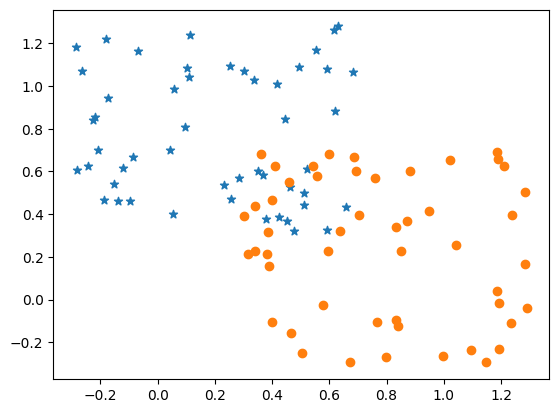

In [30]:
import matplotlib.pyplot as plt

plt.scatter(x0,y0,marker="*")
plt.scatter(x1,y1)
plt.show()

In [29]:
#ReLu activation
class Activation_Relu:
    def forward(self,inputs):
        self.output = np.maximum(0,inputs)